# 05 - EDA with Data Visualization and Feature Engineering
**IBM Applied Data Science Capstone - SpaceX Falcon 9 First-Stage Landing Prediction**

Author: Pranav Vyankatesh Jagdale

**Goal:** explore which variables relate to landing success, then prepare the encoded feature table for modelling.

> Run every cell in order. Keep your own outputs - they feed your final slides.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


## 1. Flight number vs payload mass

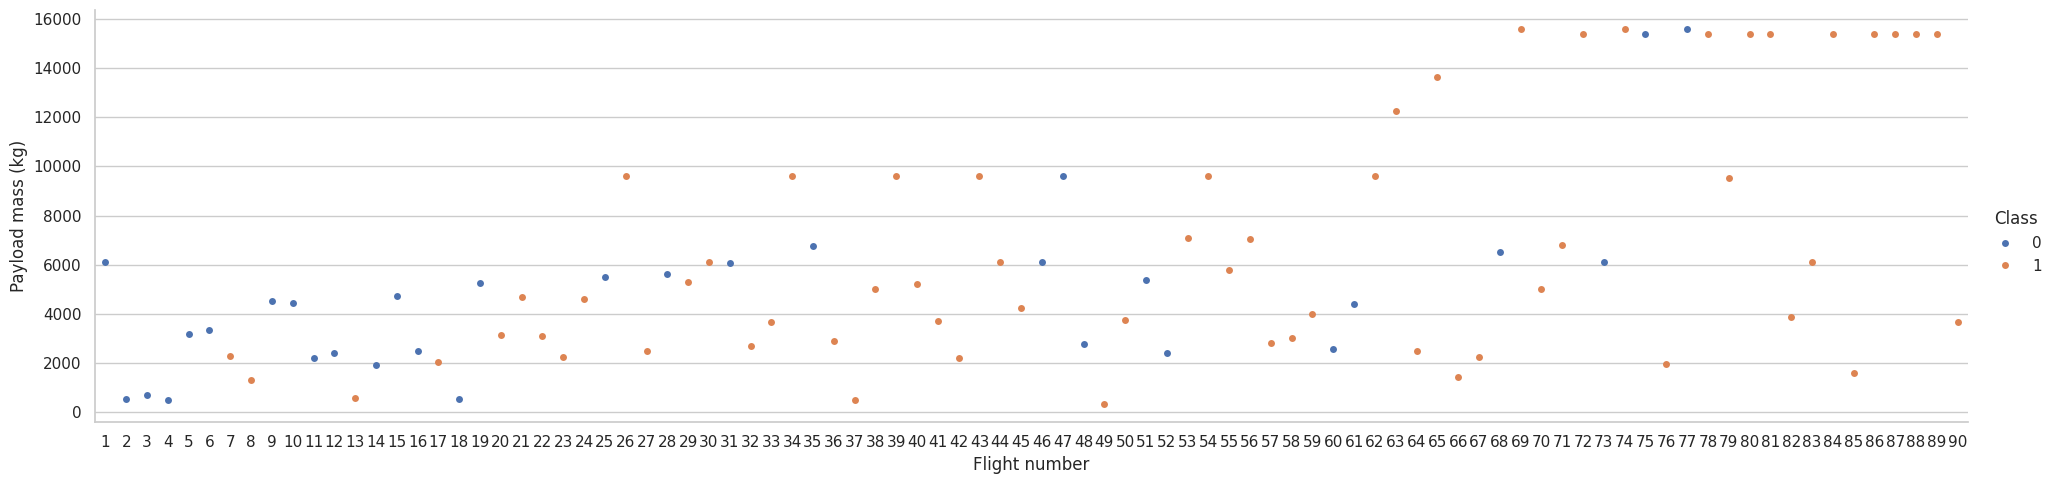

In [2]:
sns.catplot(y='PayloadMass', x='FlightNumber', hue='Class', data=df, aspect=4)
plt.xlabel('Flight number'); plt.ylabel('Payload mass (kg)')
plt.show()

## 2. Flight number vs launch site

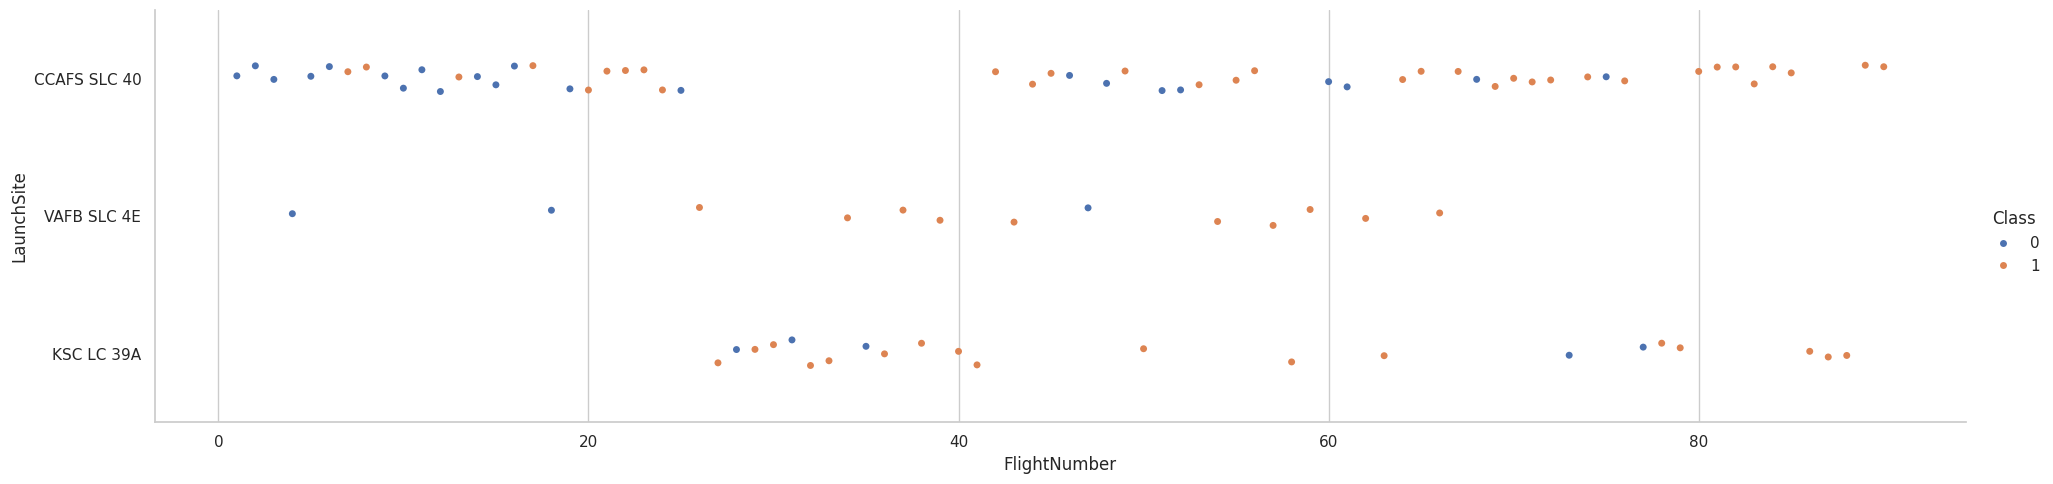

In [3]:
sns.catplot(y='LaunchSite', x='FlightNumber', hue='Class', data=df, aspect=4)
plt.show()

## 3. Payload mass vs launch site

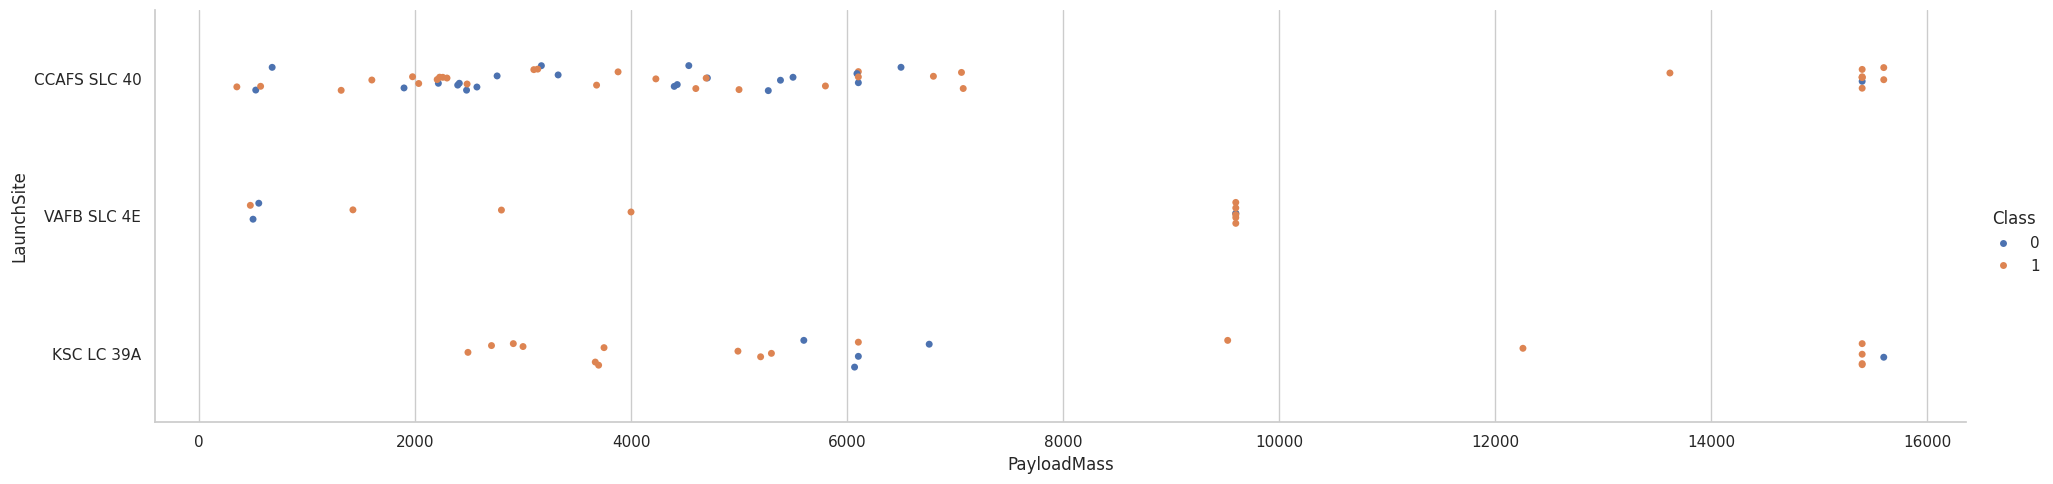

In [4]:
sns.catplot(y='LaunchSite', x='PayloadMass', hue='Class', data=df, aspect=4)
plt.show()

## 4. Success rate by orbit (also check sample sizes!)

           mean  count
Orbit                 
SO     0.000000      1
GTO    0.518519     27
ISS    0.619048     21
MEO    0.666667      3
PO     0.666667      9
LEO    0.714286      7
VLEO   0.857143     14
HEO    1.000000      1
GEO    1.000000      1
ES-L1  1.000000      1
SSO    1.000000      5


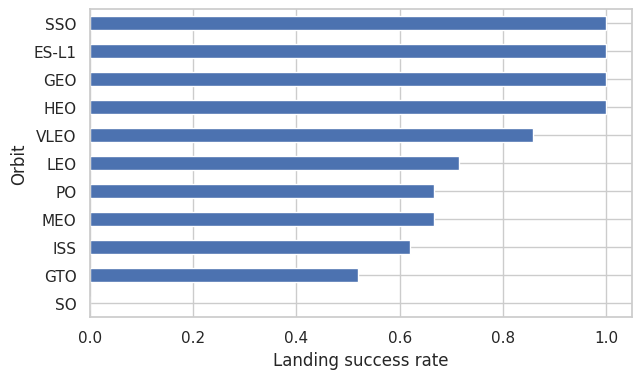

In [5]:
orbit = df.groupby('Orbit')['Class'].agg(['mean', 'count']).sort_values('mean')
print(orbit)
orbit['mean'].plot(kind='barh', figsize=(7, 4))
plt.xlabel('Landing success rate'); plt.show()

## 5. Flight number vs orbit

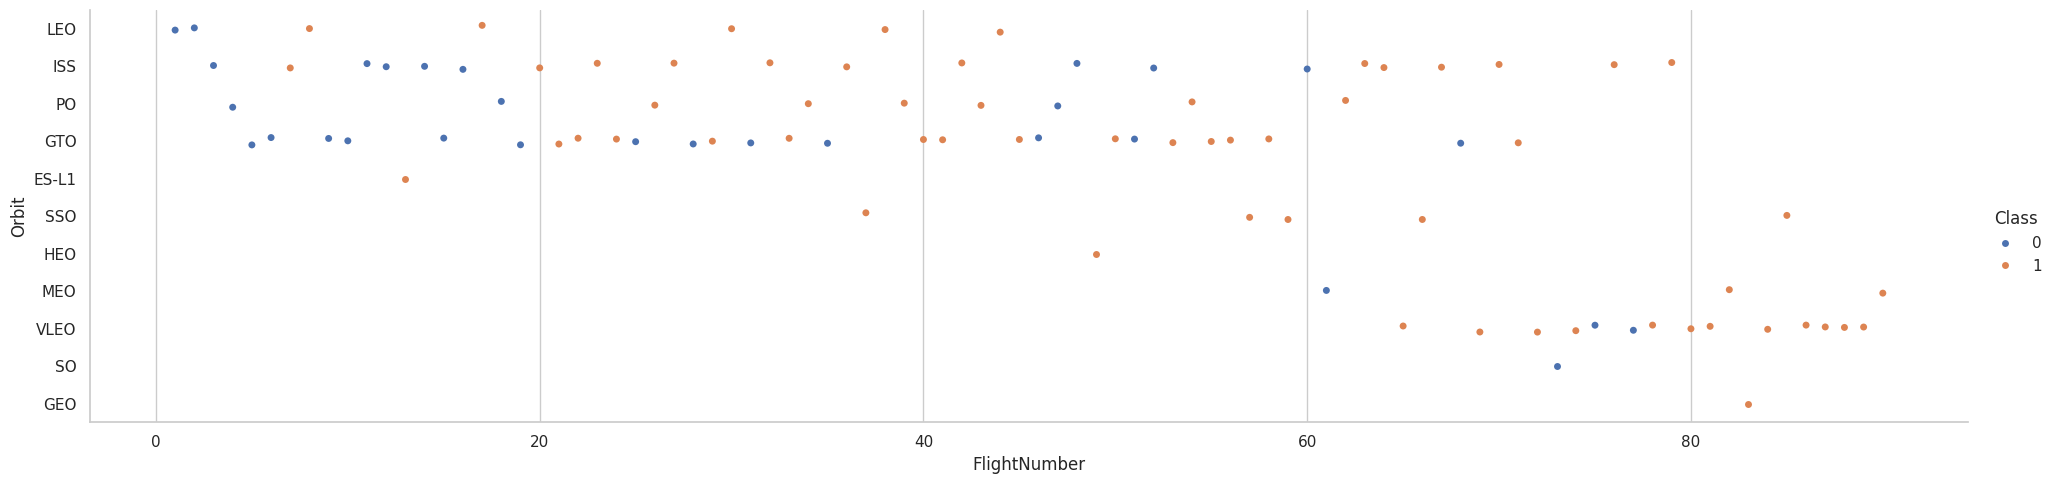

In [6]:
sns.catplot(y='Orbit', x='FlightNumber', hue='Class', data=df, aspect=4)
plt.show()

## 6. Yearly success trend

          mean  count
Year                 
2010  0.000000      1
2012  0.000000      1
2013  0.000000      3
2014  0.333333      6
2015  0.333333      6
2016  0.625000      8
2017  0.833333     18
2018  0.611111     18
2019  0.900000     10
2020  0.842105     19


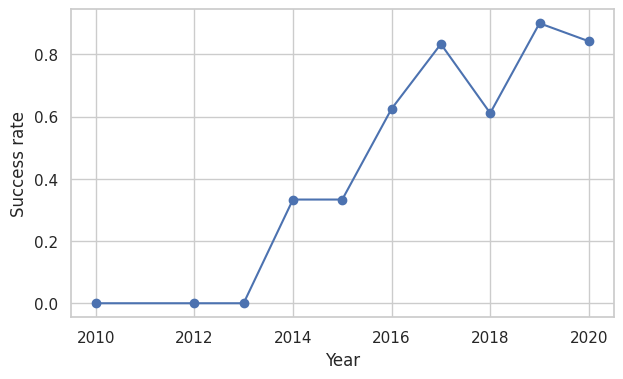

In [7]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly = df.groupby('Year')['Class'].agg(['mean', 'count'])
print(yearly)
yearly['mean'].plot(marker='o', figsize=(7, 4))
plt.ylabel('Success rate'); plt.show()

## 7. Feature engineering: select features and one-hot encode

In [8]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins',
               'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot = features_one_hot.astype('float64')
print(features_one_hot.shape)
features_one_hot.to_csv('my_dataset_part_3.csv', index=False)
features_one_hot.head()

(90, 80)


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Write your own insights here
For each plot, write one observation backed by a number. Think about: learning curve over time, small-sample orbits, site differences, payload range. At least one insight should go beyond what the lab asks.